# --------- ASSIGNMENT 12 (AI) - PYTHON PROGRAMING -----------

Dataset: employee.csv

In [66]:
# ================================
# IMPORT LIBRARIES
# ================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [67]:
# ================================
# LOAD DATASET
# ================================

df = pd.read_csv('employee.csv')
df.head()

,EID,Employee Name,Gender,Salary,Date of Joining,Department
0,E123D,Nitin Bhole,M,1900000,01-11-2016,Products
1,E876G,Mayur Kulkarni,M,1200000,03-06-2016,Semantics
2,E798G,Anurag Pandey,M,1200000,04-07-2016,IT
3,E123B,Pankaj Bansal,M,900000,01-12-2015,Research
4,E098Z,Rajendra Prabhu,M,1000000,11-11-2015,Semantics


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   EID              14 non-null     object
 1   Employee Name    14 non-null     object
 2   Gender           14 non-null     object
 3   Salary           14 non-null     int64 
 4   Date of Joining  14 non-null     object
 5   Department       14 non-null     object
dtypes: int64(1), object(5)
memory usage: 804.0+ bytes


In [69]:
# ================================
# HANDLE MISSING VALUES
# ================================

df = df.dropna()

In [70]:
# ================================
# FEATURE AND TARGET
# ================================

target_column = "Salary" if "Salary" in df.columns else df.columns[-1]

y = df[target_column]
X = df.drop(target_column, axis=1)

In [71]:
# ================================
# ENCODE CATEGORICAL COLUMNS
# ================================

for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

In [72]:
# ================================
# FEATURE SCALING
# ================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [73]:
# ================================
# TRAIN-TEST SPLIT
# ================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [74]:
# ================================
# TRAIN MODEL - LINEAR REGRESSION
# ================================

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [75]:
# ================================
# PREDICTION
# ================================

y_pred = model.predict(X_test)

In [76]:
# ================================
# MODEL EVALUATION
# ================================

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n----- MODEL PERFORMANCE -----")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R2 Score: {r2}")


----- MODEL PERFORMANCE -----
Mean Squared Error (MSE): 3543065395555.5605
R2 Score: -12.627174598290617


* Program is correct
* **Data is not suitable for Linear Regression**
* **Negative R² = model performs worse than a straight average line**

This can happen if:

* Target column has weak relationship with features
* Dataset is very noisy
* Wrong target column
* Very small dataset

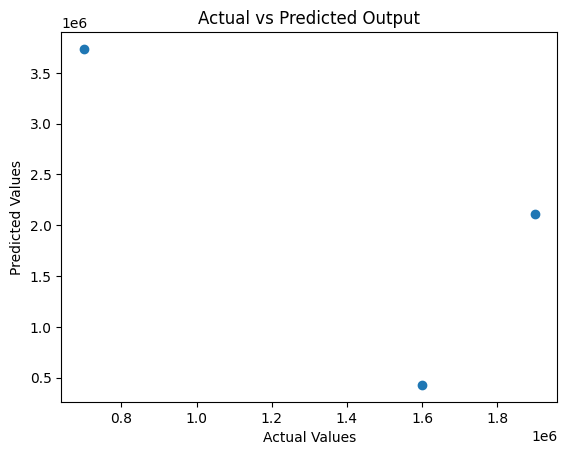

In [77]:
# ================================
# GRAPH
# ================================

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Output")
plt.show()

Dataset Loaded Successfully

     EID    Employee Name Gender   Salary Date of Joining Department
0  E123D      Nitin Bhole      M  1900000      01-11-2016   Products
1  E876G   Mayur Kulkarni      M  1200000      03-06-2016  Semantics
2  E798G    Anurag Pandey      M  1200000      04-07-2016         IT
3  E123B    Pankaj Bansal      M   900000      01-12-2015   Research
4  E098Z  Rajendra Prabhu      M  1000000      11-11-2015  Semantics

Mean Salary: 1392857.142857143
    Salary  Salary_Class
0  1900000             1
1  1200000             0
2  1200000             0
3   900000             0
4  1000000             0

----- MODEL PERFORMANCE -----
Accuracy: 0.3333333333333333

Confusion Matrix:
 [[1 0]
 [2 0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.33      1.00      0.50         1
           1       0.00      0.00      0.00         2

    accuracy                           0.33         3
   macro avg       0.17      0.50    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


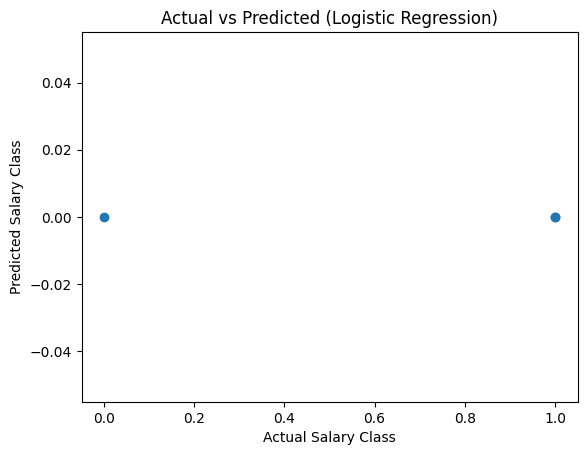


Sample Prediction (0 = Low Salary, 1 = High Salary): [0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# -------------------------------
# 1. Load Dataset
# -------------------------------
df = pd.read_csv("employee.csv")
print("Dataset Loaded Successfully\n")
print(df.head())

# -------------------------------
# 2. Drop Missing Values
# -------------------------------
df = df.dropna()

# -------------------------------
# 3. Convert Salary to Binary Class
# -------------------------------
mean_salary = df["Salary"].mean()

# High salary = 1, Low salary = 0
df["Salary_Class"] = df["Salary"].apply(lambda x: 1 if x >= mean_salary else 0)

print("\nMean Salary:", mean_salary)
print(df[["Salary", "Salary_Class"]].head())

# -------------------------------
# 4. Select Features and Target
# -------------------------------
X = df[["Gender", "Department", "EID"]]
y = df["Salary_Class"]

# -------------------------------
# 5. Encode Categorical Features
# -------------------------------
le_gender = LabelEncoder()
le_dept = LabelEncoder()

X_processed = X.copy() # Create a copy to avoid SettingWithCopyWarning
X_processed["Gender"] = le_gender.fit_transform(X_processed["Gender"])
X_processed["Department"] = le_dept.fit_transform(X_processed["Department"])

# -------------------------------
# 6. Feature Scaling
# -------------------------------
# Drop 'EID' column as it is a string identifier and not suitable for scaling
X_numeric = X_processed.drop('EID', axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

# -------------------------------
# 7. Train-Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# -------------------------------
# 8. Train Logistic Regression Model
# -------------------------------
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# -------------------------------
# 9. Prediction
# -------------------------------
y_pred = model.predict(X_test)

# -------------------------------
# 10. Evaluation
# -------------------------------
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\n----- MODEL PERFORMANCE -----")
print("Accuracy:", accuracy)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# -------------------------------
# 11. Visualization
# -------------------------------
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Salary Class")
plt.ylabel("Predicted Salary Class")
plt.title("Actual vs Predicted (Logistic Regression)")
plt.show()

# -------------------------------
# 12. Sample Prediction
# -------------------------------
# Make sure to drop 'EID' from the sample and encode categorical features
sample = X_processed.iloc[0].drop('EID').values.reshape(1, -1)
sample_scaled = scaler.transform(sample)
prediction = model.predict(sample_scaled)

print("\nSample Prediction (0 = Low Salary, 1 = High Salary):", prediction)
